In [1]:
import pandas as pd
import numpy as np

In [2]:
# Read the data
df = pd.read_csv("Cars_4vars.csv")

In [3]:
df.shape
df.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HP      81 non-null     int64  
 1   MPG     81 non-null     float64
 2   VOL     81 non-null     int64  
 3   SP      81 non-null     float64
 4   WT      81 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 3.3 KB


In [5]:
# Check for missing values
df.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [6]:
# Correlation Matrix
df.corr()

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
y_multi = df["MPG"]

In [9]:
# Define different models based on adding features step by step from highest correlation with MPG

# Model1: Using only HP (highest correlation with MPG)

x_model1 = df[['HP']]
model1 = LinearRegression()
model1.fit(x_model1,y_multi)
y_pred1 = model1.predict(x_model1)
r2_model1 = r2_score(y_multi, y_pred1)
rmse_model1 = np.sqrt(mean_squared_error(y_multi, y_pred1))

In [10]:
# Model2: Using HP + SP (next highest correlation)

x_model2 = df[['HP','SP']]
model2 = LinearRegression()
model2.fit(x_model2,y_multi)
y_pred2 = model2.predict(x_model2)
r2_model2 = r2_score(y_multi, y_pred2)
rmse_model2 = np.sqrt(mean_squared_error(y_multi, y_pred2))

In [11]:
# Model3: Using HP + Sp + VOL (next highest correlation)

x_model3 = df[['HP','SP','VOL']]
model3 = LinearRegression()
model3.fit(x_model3,y_multi)
y_pred3 = model3.predict(x_model3)
r2_model3 = r2_score(y_multi, y_pred3)
rmse_model3 = np.sqrt(mean_squared_error(y_multi, y_pred3))

In [12]:
# Model4: Using HP + SP + VOL + WT (all variables)

x_model4 = df[['HP','SP','VOL','WT']]
model4 = LinearRegression()
model4.fit(x_model4,y_multi)
y_pred4 = model4.predict(x_model4)
r2_model4 = r2_score(y_multi, y_pred4)
rmse_model4 = np.sqrt(mean_squared_error(y_multi, y_pred4))

In [13]:
# Store results ina DataFrame

In [14]:
model_results = pd.DataFrame({
    "Model" : ["HP Only","HP+SP","HP+SP+VOL","HP+SP+VOL+WT"],
    "R-Squared" : [r2_model1, r2_model2, r2_model3, r2_model4],
    "RMSE" : [rmse_model1, rmse_model2, rmse_model3, rmse_model4],
})

In [15]:
# Display the results
print(model_results)

          Model  R-Squared      RMSE
0       HP Only   0.525681  6.249963
1         HP+SP   0.532639  6.203948
2     HP+SP+VOL   0.770368  4.348684
3  HP+SP+VOL+WT   0.770537  4.347084


In [16]:
# Define Independent variable (x) as SP and Dependent variable (y) as HP

In [17]:
x_sp = df[['SP']]
y_hp = df ['HP']

#Fit a LinearRegression model

model_sp_hp = LinearRegression()
model_sp_hp.fit(x_sp,y_hp)

#Predict HP using SP

y_hp_pred = model_sp_hp.predict(x_sp)

#Calculate R-Squared for the model

r2_sp_hp = r2_score(y_hp,y_hp_pred)

# Calculate VIF using R-Squared

vif_hp_sp = 1/(1-r2_sp_hp)

In [18]:
#Display the results

print("R-Squared", r2_sp_hp)
print("VIF", vif_hp_sp)

R-Squared 0.9483800677016775
VIF 19.372361711379014


In [19]:
#=================================================================================================================

In [20]:
# Define Independent variable (x) as VOL and Dependent variable (y) as WT

In [21]:
x_vol = df[['VOL']]
y_wt = df['WT']

model_vol_wt = LinearRegression()
model_vol_wt.fit(x_vol,y_wt)

y_wt_pred = model_vol_wt.predict(x_vol)

r2_vol_wt = r2_score(y_wt,y_wt_pred)

vif_vol_wt = 1/(1-r2_vol_wt)

In [22]:
print ("R-Squared", r2_vol_wt)
print ("VIF :", vif_vol_wt)

R-Squared 0.9984067954549005
VIF : 627.6657966335137


In [23]:
#============================================================================================

In [24]:
# Define Independent variable (x) as VOL and Dependent variable (y) as HP

In [25]:
x_vol = df[['VOL']]
y_hp = df['HP']

model_vol_hp = LinearRegression()
model_vol_hp.fit(x_vol,y_hp)

y_hp_pred = model_vol_hp.predict(x_vol)

r2_vol_hp = r2_score(y_hp,y_hp_pred)

vif_vol_hp = 1/(1-r2_vol_hp)

In [26]:
print ("R-Squared :",r2_vol_hp)
print ("VIF :",vif_vol_hp)

R-Squared : 0.005999970050444947
VIF : 1.0060361869916135


In [27]:
#===============================================================================================

In [28]:
# Model 2: Using HP + VOL (next highest correlation features)

In [29]:
x_best = df[['HP','VOL']]

model5 = LinearRegression()
model5.fit(x_best,y_multi)
y_pred2 = model5.predict(x_best)
r2_model2 = r2_score(y_multi,y_pred2)
rmse_model2 = np.sqrt(mean_squared_error(y_multi,y_pred2))

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Compute residuals for the HP + VOL model

residuals = y_multi - y_pred2

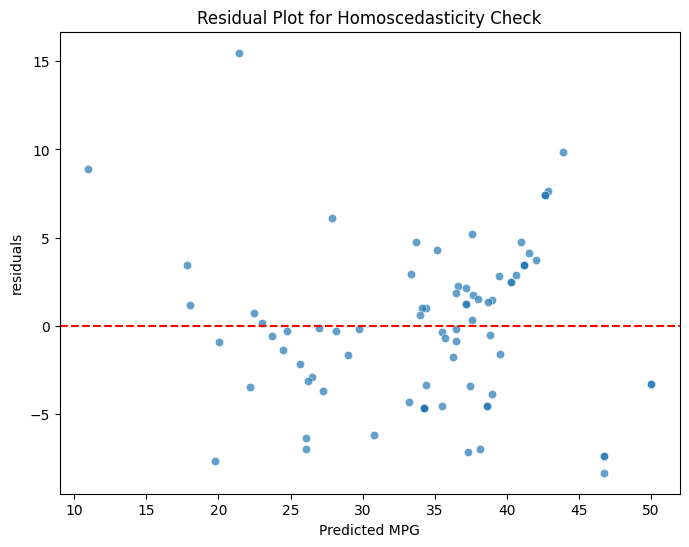

In [33]:
# Plot residuals vs Predicted values

plt.figure(figsize =(8,6))
sns.scatterplot(x = y_pred2, y = residuals, alpha = 0.7)
plt.axhline(y = 0,color = 'red', linestyle = '--')
plt.xlabel("Predicted MPG")
plt.ylabel("residuals")
plt.title("Residual Plot for Homoscedasticity Check")
plt.show()